# An Introduction to Runge–Kutta Methods

## Purpose of this notebook

Runge–Kutta methods advance the solution of an initial-value problem

$$\frac{dy}{dt}=f(t,y), \qquad y(t_0)=y_0.$$

This notebook compares four explicit methods of increasing order:

- forward Euler, also called RK1;
- the explicit trapezoid or Heun method, an RK2 method;
- Kutta's classical third-order method, RK3; and
- the classical fourth-order method, RK4.

We will first take one deliberately large step so that the methods visibly differ. We will then integrate the same fixed interval with successively smaller timesteps and measure the convergence order. The convergence study—not the result of one carefully chosen step—is the meaningful test of a numerical algorithm.

## Test equation and analytical solution

Consider

$$\frac{dy}{dt}=t^2y, \qquad y(0)=1.$$

This equation is separable:

$$\frac{dy}{y}=t^2\,dt,$$

so

$$\ln y=\frac{t^3}{3}+C.$$

The initial condition gives $C=0$, and therefore

$$y(t)=\exp\left(\frac{t^3}{3}\right).$$

The analytical solution provides an independent benchmark for every numerical result below.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def derivative(t, y):
    '''Right-hand side f(t, y) = t^2 y.'''
    return t**2*y


def exact_solution(t):
    '''Analytical solution satisfying y(0) = 1.'''
    return np.exp(np.asarray(t)**3/3.0)


t0 = 0.0
y0 = 1.0
t_final = 1.0

## RK1: forward Euler

Euler's method evaluates the slope once, at the beginning of the step:

$$k_1=f(t_n,y_n),$$

$$y_{n+1}=y_n+h k_1.$$

It follows the current tangent line for the entire timestep. Its local truncation error is $O(h^2)$ and its accumulated global error over a fixed interval is $O(h)$. Euler is therefore called a first-order method.

In [2]:
def euler_step(t, y, h):
    k1 = derivative(t, y)
    return y+h*k1

## RK2: explicit trapezoid (Heun) method

RK2 first uses the beginning slope to predict an endpoint and then evaluates a second slope there:

$$k_1=f(t_n,y_n),$$

$$k_2=f(t_n+h,y_n+h k_1),$$

$$y_{n+1}=y_n+\frac{h}{2}(k_1+k_2).$$

The final update averages the two slopes. This is analogous to the trapezoid rule for integration. The method has local error $O(h^3)$ and global error $O(h^2)$.

In [3]:
def rk2_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t+h, y+h*k1)
    return y+0.5*h*(k1+k2)

## RK3: Kutta's classical third-order method

A valid third-order method requires three slopes with carefully chosen trial states:

$$k_1=f(t_n,y_n),$$

$$k_2=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_1\right),$$

$$k_3=f(t_n+h,y_n-hk_1+2hk_2),$$

$$y_{n+1}=y_n+\frac{h}{6}(k_1+4k_2+k_3).$$

The term $y_n-hk_1+2hk_2$ in the third trial state is essential. Replacing it with $y_n+hk_2$ produces a method that satisfies some third-order conditions but not all of them; it remains only second-order. The method below has local error $O(h^4)$ and global error $O(h^3)$.

In [4]:
def rk3_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t+0.5*h, y+0.5*h*k1)
    k3 = derivative(t+h, y-h*k1+2.0*h*k2)
    return y+(h/6.0)*(k1+4.0*k2+k3)

## RK4: classical fourth-order method

Classical RK4 samples the slope at the beginning, twice near the midpoint, and once at the endpoint:

$$k_1=f(t_n,y_n),$$

$$k_2=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_1\right),$$

$$k_3=f\left(t_n+\frac{h}{2},y_n+\frac{h}{2}k_2\right),$$

$$k_4=f(t_n+h,y_n+hk_3),$$

$$y_{n+1}=y_n+\frac{h}{6}(k_1+2k_2+2k_3+k_4).$$

The half-step factors and weights are fixed by the RK4 order conditions; they are not parameters to tune against a known answer. Classical RK4 has local error $O(h^5)$ and global error $O(h^4)$.

In [5]:
def rk4_step(t, y, h):
    k1 = derivative(t, y)
    k2 = derivative(t+0.5*h, y+0.5*h*k1)
    k3 = derivative(t+0.5*h, y+0.5*h*k2)
    k4 = derivative(t+h, y+h*k3)
    return y+(h/6.0)*(k1+2.0*k2+2.0*k3+k4)


methods = {
    'Euler / RK1': euler_step,
    'Heun / RK2': rk2_step,
    'Kutta / RK3': rk3_step,
    'Classical RK4': rk4_step,
}

## One large step

We first advance directly from $t=0$ to $t=1$ with one step of size $h=1$. This is intentionally demanding. The calculation illustrates that higher-order methods use additional derivative information effectively, but it does **not** by itself prove their formal orders.

The relative error is calculated as

$$100\left|\frac{y_{\mathrm{estimate}}-y_{\mathrm{exact}}}
{y_{\mathrm{exact}}}\right|.$$

In [6]:
h = t_final-t0
exact_final = exact_solution(t_final)
one_step_estimates = {}

print(f"Exact y({t_final:g}) = {exact_final:.10f}\n")
for name, stepper in methods.items():
    estimate = stepper(t0, y0, h)
    one_step_estimates[name] = estimate
    relative_error = 100.0*abs((estimate-exact_final)/exact_final)
    print(f"{name:14s}: estimate={estimate:.10f}, "
          f"relative error={relative_error:.5f}%")

Exact y(1) = 1.3956124251

Euler / RK1   : estimate=1.0000000000, relative error=28.34687%
Heun / RK2    : estimate=1.5000000000, relative error=7.47970%
Kutta / RK3   : estimate=1.4166666667, relative error=1.50860%
Classical RK4 : estimate=1.3906250000, relative error=0.35736%


## How each method evolves toward its estimate

The four panels below expose the internal construction of one large step. A point labeled $k_i$ marks the temporary state at which derivative $k_i$ is evaluated. The dashed path connects those trial states in the order in which the algorithm constructs them. The square at $t_{n+1}$ is the final estimate after the method combines its slopes.

These trial states are not a sequence of accepted solution values. Every method starts from the same $(t_n,y_n)$ and produces only one accepted endpoint. Higher-order methods gather more information about how the derivative changes inside the interval before constructing that endpoint.

- **RK1** sees only the initial slope. Here that slope is zero, so its estimate does not move.
- **RK2** uses the RK1 endpoint prediction to evaluate a second slope, then averages the two slopes.
- **RK3** evaluates a midpoint state and uses it to construct a specially corrected endpoint trial before applying its weighted average.
- **RK4** uses two distinct midpoint trials and one endpoint trial before combining all four slopes.

The exact curve is included only as a benchmark. None of the numerical methods uses it when constructing its estimate.

In every panel, short **solid orange tangent segments** show the slopes returned by the differential equation at the trial states. Lighter dashed orange lines show how those slopes construct the next trial state. A stronger dashed orange line starts from $(t_n,y_n)$ and uses the method's final weighted slope to reach the accepted red-square estimate.

The labels are attached to the tangent segments and identify their actual slopes. The trial-state markers therefore need no separate bare $k_i$ labels.

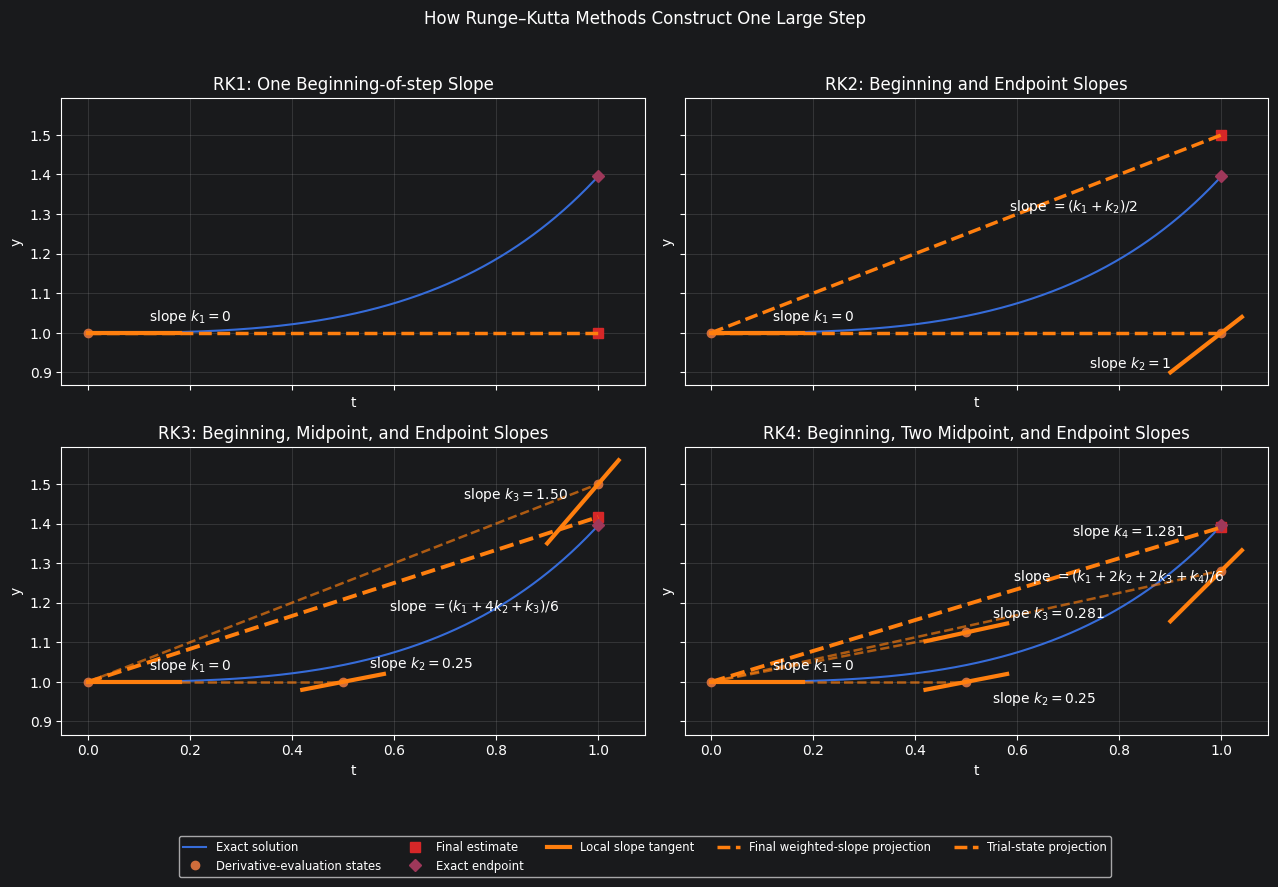

In [12]:
def plot_stage_construction(ax, title, stage_times, stage_values,
                            stage_labels, final_estimate, connect_stages=True):
    # No explicit colors are assigned: Matplotlib selects colors from the
    # active theme, so the figure remains readable in light and dark modes.
    ax.plot(t_dense, exact_solution(t_dense), label='Exact solution')
    stage_style = 'o--' if connect_stages else 'o'
    ax.plot(stage_times, stage_values, stage_style,
            label='Derivative-evaluation states')
    ax.plot(t_final, final_estimate, 's', color='tab:red',
            markersize=7, label='Final estimate')
    ax.plot(t_final, exact_final, 'D', markersize=6, label='Exact endpoint')

    ax.set_title(title)
    ax.set_xlabel('t')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.25)


h = t_final-t0
t_dense = np.linspace(t0, t_final, 400)

# RK1: one derivative at the initial state
rk1_k1 = derivative(t0, y0)
rk1_final = y0+h*rk1_k1

# RK2: initial state followed by the Euler endpoint predictor
rk2_k1 = derivative(t0, y0)
rk2_stage2 = y0+h*rk2_k1
rk2_k2 = derivative(t0+h, rk2_stage2)
rk2_final = y0+0.5*h*(rk2_k1+rk2_k2)

# RK3: initial, midpoint, and corrected endpoint trial states
rk3_k1 = derivative(t0, y0)
rk3_stage2 = y0+0.5*h*rk3_k1
rk3_k2 = derivative(t0+0.5*h, rk3_stage2)
rk3_stage3 = y0-h*rk3_k1+2.0*h*rk3_k2
rk3_k3 = derivative(t0+h, rk3_stage3)
rk3_final = y0+(h/6.0)*(rk3_k1+4.0*rk3_k2+rk3_k3)

# RK4: initial, two midpoint, and endpoint trial states
rk4_k1 = derivative(t0, y0)
rk4_stage2 = y0+0.5*h*rk4_k1
rk4_k2 = derivative(t0+0.5*h, rk4_stage2)
rk4_stage3 = y0+0.5*h*rk4_k2
rk4_k3 = derivative(t0+0.5*h, rk4_stage3)
rk4_stage4 = y0+h*rk4_k3
rk4_k4 = derivative(t0+h, rk4_stage4)
rk4_final = y0+(h/6.0)*(rk4_k1+2.0*rk4_k2+2.0*rk4_k3+rk4_k4)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

plot_stage_construction(
    axes[0, 0], 'RK1: One Beginning-of-step Slope',
    [t0], [y0], ['$k_1$'], rk1_final, connect_stages=False,
)
plot_stage_construction(
    axes[0, 1], 'RK2: Beginning and Endpoint Slopes',
    [t0, t0+h], [y0, rk2_stage2], ['$k_1$', '$k_2$'], rk2_final,
    connect_stages=False,
)

# Board-style geometric construction for RK1 and RK2
tangent_color = 'tab:orange'

# RK1: show the initial tangent, then extend it across the full timestep.
initial_span = np.linspace(t0, t0+0.18*h, 30)
initial_tangent = y0+rk1_k1*(initial_span-t0)
axes[0, 0].plot(initial_span, initial_tangent, color=tangent_color,
                linewidth=3, label='Local slope tangent')
axes[0, 0].plot([t0, t0+h], [y0, rk1_final], '--', color=tangent_color,
                linewidth=2.5, label='Final weighted-slope projection')
axes[0, 0].annotate(r'slope $k_1=0$', (t0+0.12*h, y0),
                    xytext=(0, 9), textcoords='offset points')

# RK2: the first tangent projects to a provisional endpoint at (t0+h, y0+h*k1).
axes[0, 1].plot(initial_span, initial_tangent, color=tangent_color,
                linewidth=3, label='Local slope tangent')
axes[0, 1].plot([t0, t0+h], [y0, rk2_stage2], '--', color=tangent_color,
                linewidth=2.5, label='Trial-state projection')
axes[0, 1].annotate(r'slope $k_1=0$', (t0+0.12*h, y0),
                    xytext=(0, 9), textcoords='offset points')

# Evaluate k2 at that provisional state and draw its local tangent.
endpoint_span = np.linspace(t0+0.90*h, t0+1.04*h, 30)
endpoint_tangent = rk2_stage2+rk2_k2*(endpoint_span-(t0+h))
axes[0, 1].plot(endpoint_span, endpoint_tangent, color=tangent_color,
                linewidth=3, label='Local slope tangent')
axes[0, 1].annotate(r'slope $k_2=1$',
                    (t0+0.93*h, rk2_stage2-0.07*h*rk2_k2),
                    xytext=(-70, -5), textcoords='offset points')

# The accepted RK2 estimate uses the average of the two slopes.
average_slope = 0.5*(rk2_k1+rk2_k2)
axes[0, 1].plot([t0, t0+h], [y0, y0+h*average_slope], '--',
                color=tangent_color, linewidth=2.5,
                label='Final weighted-slope projection')
axes[0, 1].annotate(r'slope $=(k_1+k_2)/2$',
                    (t0+0.57*h, y0+0.57*h*average_slope),
                    xytext=(5, 7), textcoords='offset points')

plot_stage_construction(
    axes[1, 0], 'RK3: Beginning, Midpoint, and Endpoint Slopes',
    [t0, t0+0.5*h, t0+h], [y0, rk3_stage2, rk3_stage3],
    ['$k_1$', '$k_2$', '$k_3$'], rk3_final, connect_stages=False,
)
plot_stage_construction(
    axes[1, 1], 'RK4: Beginning, Two Midpoint, and Endpoint Slopes',
    [t0, t0+0.5*h, t0+0.5*h, t0+h],
    [y0, rk4_stage2, rk4_stage3, rk4_stage4],
    ['$k_1$', '$k_2$', '$k_3$', '$k_4$'], rk4_final,
    connect_stages=False,
)


# RK3 board-style construction ------------------------------------------------
rk3_ax = axes[1, 0]
rk3_ax.plot(initial_span, y0+rk3_k1*(initial_span-t0),
            color=tangent_color, linewidth=3, label='Local slope tangent')
rk3_ax.annotate(r'slope $k_1=0$', (t0+0.12*h, y0),
                xytext=(0, 9), textcoords='offset points')

midpoint_span = np.linspace(t0+0.42*h, t0+0.58*h, 30)
rk3_midpoint_tangent = rk3_stage2+rk3_k2*(midpoint_span-(t0+0.5*h))
rk3_ax.plot(midpoint_span, rk3_midpoint_tangent,
            color=tangent_color, linewidth=3)
rk3_ax.annotate(r'slope $k_2=0.25$', (t0+0.54*h, rk3_stage2+0.04*h*rk3_k2),
                xytext=(4, 7), textcoords='offset points')

rk3_endpoint_span = np.linspace(t0+0.90*h, t0+1.04*h, 30)
rk3_endpoint_tangent = rk3_stage3+rk3_k3*(rk3_endpoint_span-(t0+h))
rk3_ax.plot(rk3_endpoint_span, rk3_endpoint_tangent,
            color=tangent_color, linewidth=3)
rk3_ax.annotate(r'slope $k_3=1.50$',
                (t0+0.94*h, rk3_stage3-0.06*h*rk3_k3),
                xytext=(-75, 15), textcoords='offset points')

# Lighter dashed projections construct the midpoint and corrected endpoint trials.
rk3_ax.plot([t0, t0+0.5*h], [y0, rk3_stage2], '--', color=tangent_color,
            linewidth=1.8, alpha=0.65, label='Trial-state projection')
rk3_ax.plot([t0, t0+h], [y0, rk3_stage3], '--', color=tangent_color,
            linewidth=1.8, alpha=0.65)
rk3_weighted_slope = (rk3_k1+4.0*rk3_k2+rk3_k3)/6.0
rk3_ax.plot([t0, t0+h], [y0, rk3_final], '--', color=tangent_color,
            linewidth=2.8, label='Final weighted-slope projection')
rk3_ax.annotate(r'slope $=(k_1+4k_2+k_3)/6$',
                (t0+0.58*h, y0+0.58*h*rk3_weighted_slope),
                xytext=(4, -18), textcoords='offset points')


# RK4 board-style construction ------------------------------------------------
rk4_ax = axes[1, 1]
rk4_ax.plot(initial_span, y0+rk4_k1*(initial_span-t0),
            color=tangent_color, linewidth=3, label='Local slope tangent')
rk4_ax.annotate(r'slope $k_1=0$', (t0+0.12*h, y0),
                xytext=(0, 9), textcoords='offset points')

rk4_k2_tangent = rk4_stage2+rk4_k2*(midpoint_span-(t0+0.5*h))
rk4_ax.plot(midpoint_span, rk4_k2_tangent, color=tangent_color, linewidth=3)
rk4_ax.annotate(r'slope $k_2=0.25$', (t0+0.54*h, rk4_stage2+0.04*h*rk4_k2),
                xytext=(4, -18), textcoords='offset points')

rk4_k3_tangent = rk4_stage3+rk4_k3*(midpoint_span-(t0+0.5*h))
rk4_ax.plot(midpoint_span, rk4_k3_tangent, color=tangent_color, linewidth=3)
rk4_ax.annotate(r'slope $k_3=0.281$', (t0+0.54*h, rk4_stage3+0.04*h*rk4_k3),
                xytext=(4, 7), textcoords='offset points')

rk4_endpoint_span = np.linspace(t0+0.90*h, t0+1.04*h, 30)
rk4_k4_tangent = rk4_stage4+rk4_k4*(rk4_endpoint_span-(t0+h))
rk4_ax.plot(rk4_endpoint_span, rk4_k4_tangent,
            color=tangent_color, linewidth=3)
rk4_ax.annotate(r'slope $k_4=1.281$',
                (t0+1.02*h, rk4_stage4+0.02*h*rk4_k4),
                xytext=(-115, 18), textcoords='offset points')

# Each lighter projection starts at the accepted initial state and constructs
# the trial state needed for the next derivative evaluation.
rk4_ax.plot([t0, t0+0.5*h], [y0, rk4_stage2], '--', color=tangent_color,
            linewidth=1.8, alpha=0.65, label='Trial-state projection')
rk4_ax.plot([t0, t0+0.5*h], [y0, rk4_stage3], '--', color=tangent_color,
            linewidth=1.8, alpha=0.65)
rk4_ax.plot([t0, t0+h], [y0, rk4_stage4], '--', color=tangent_color,
            linewidth=1.8, alpha=0.65)

rk4_weighted_slope = (rk4_k1+2.0*rk4_k2+2.0*rk4_k3+rk4_k4)/6.0
rk4_ax.plot([t0, t0+h], [y0, rk4_final], '--', color=tangent_color,
            linewidth=2.8, label='Final weighted-slope projection')
rk4_ax.annotate(r'slope $=(k_1+2k_2+2k_3+k_4)/6$',
                (t0+0.58*h, y0+0.58*h*rk4_weighted_slope),
                xytext=(4, 8), textcoords='offset points')


handles, labels = [], []
for axis in axes.flat:
    axis_handles, axis_labels = axis.get_legend_handles_labels()
    for handle, label in zip(axis_handles, axis_labels):
        if label not in labels:
            handles.append(handle)
            labels.append(label)
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=5, fontsize='small')
fig.suptitle('How Runge–Kutta Methods Construct One Large Step')
plt.tight_layout(rect=(0, 0.11, 1, 0.96))
plt.show()

## A genuine convergence test

To measure global convergence order, every method now integrates the same fixed interval $0\leq t\leq1$. We use $N$ equal steps, so $h=1/N$, and compare the final numerical value with the same exact endpoint.

If a method has global order $p$,

$$E(h)\approx Ch^p.$$

Halving $h$ should reduce the error by approximately $2^p$. Equivalently,

$$p\approx\log_2\left(\frac{E(h)}{E(h/2)}\right).$$

This comparison tests the algorithm over repeated steps and is much harder to manipulate accidentally than tuning an internal coefficient for one known endpoint.

In [8]:
def integrate_fixed_interval(stepper, n_steps):
    h = (t_final-t0)/n_steps
    t = t0
    y = y0
    for _ in range(n_steps):
        y = stepper(t, y, h)
        t += h
    return y


step_counts = 2**np.arange(0, 8)
step_sizes = (t_final-t0)/step_counts
errors = {}

for name, stepper in methods.items():
    estimates = np.array([
        integrate_fixed_interval(stepper, int(n_steps))
        for n_steps in step_counts
    ])
    method_errors = np.abs(estimates-exact_final)
    errors[name] = method_errors
    observed_order = np.log2(method_errors[-2]/method_errors[-1])
    print(f"{name:14s}: finest-grid error={method_errors[-1]:.3e}, "
          f"observed order={observed_order:.3f}")

Euler / RK1   : finest-grid error=6.487e-03, observed order=0.988
Heun / RK2    : finest-grid error=1.207e-05, observed order=1.988
Kutta / RK3   : finest-grid error=3.360e-08, observed order=2.988
Classical RK4 : finest-grid error=4.257e-12, observed order=4.103


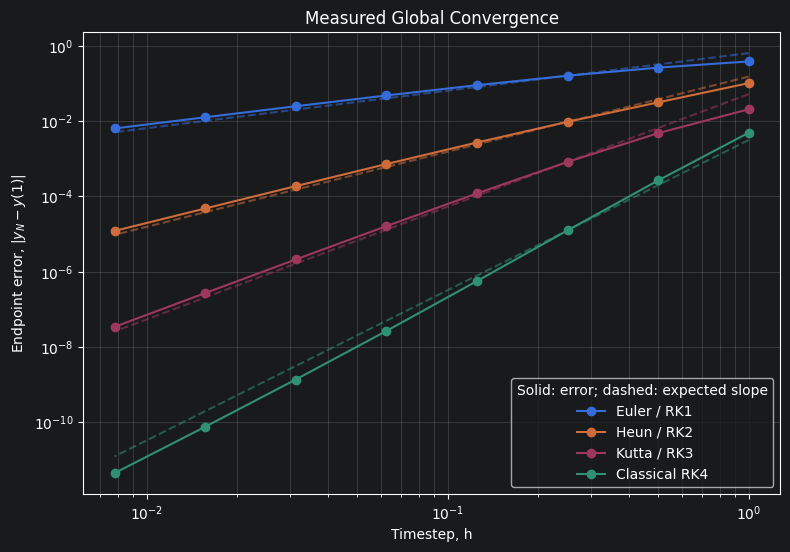

In [9]:
expected_orders = {
    'Euler / RK1': 1,
    'Heun / RK2': 2,
    'Kutta / RK3': 3,
    'Classical RK4': 4,
}

fig, ax = plt.subplots(figsize=(9, 6))
for name, method_errors in errors.items():
    line, = ax.loglog(step_sizes, method_errors, 'o-', label=name)
    order = expected_orders[name]
    reference = method_errors[2]*(step_sizes/step_sizes[2])**order
    ax.loglog(step_sizes, reference, '--', color=line.get_color(), alpha=0.55)

ax.set_xlabel('Timestep, h')
ax.set_ylabel(r'Endpoint error, $|y_N-y(1)|$')
ax.set_title('Measured Global Convergence')
ax.legend(title='Solid: error; dashed: expected slope')
ax.grid(True, which='both', alpha=0.3)
plt.show()

## Conclusions

The convergence experiment should recover orders close to 1, 2, 3, and 4 for Euler, Heun, Kutta RK3, and classical RK4. This demonstrates the meaning of “order”: it describes how error changes as the timestep is systematically reduced over a fixed problem.

An **adaptive** method would change $h$ in response to a local-error estimate while preserving the RK stage coefficients. Varying the midpoint divisor until one endpoint matches a known answer is parameter fitting, not adaptive integration, and generally destroys the method's order conditions. Adaptive step doubling and its implementation requirements are discussed separately in [`rk_functions.ipynb`](rk_functions.ipynb).

The next application will use RK4 on a vector state for orbital motion. The scalar formulas developed here apply component by component to that coupled system.